In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
# read the pickle file
with open('../data/artifacts/tracker_stubs/ball_detections_pickleball_highlights.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [14]:
from pathlib import Path
import pickle
p = Path('../data/artifacts/tracker_stubs/ball_detections_pickleball_highlights.pkl')
print("exists:", p.exists())
print("size (bytes):", p.stat().st_size if p.exists() else None)
with open(p, 'rb') as f:
    data = pickle.load(f)
print(type(data), len(data))
# show first 50 frames with brief repr
for i, frame in enumerate(data[:50]):
    print(i, repr(frame)[:200])
# summary
print("non-empty frames:", sum(bool(f) for f in data))

exists: True
size (bytes): 8914
<class 'list'> 407
0 {0: [523.0, 148.0, 538.0, 162.0]}
1 {0: [517.0, 157.0, 533.0, 171.0]}
2 {0: [513.0, 167.0, 528.0, 180.0]}
3 {}
4 {0: [500.0, 189.0, 515.0, 203.0]}
5 {0: [495.0, 203.0, 510.0, 217.0]}
6 {0: [486.0, 218.0, 504.0, 234.0]}
7 {0: [479.0, 234.0, 495.0, 250.0]}
8 {0: [470.0, 255.0, 486.0, 270.0]}
9 {0: [462.0, 275.0, 479.0, 291.0]}
10 {0: [452.0, 299.0, 471.0, 317.0]}
11 {}
12 {0: [428.0, 352.0, 453.0, 373.0]}
13 {0: [417.0, 383.0, 443.0, 405.0]}
14 {0: [406.0, 401.0, 430.0, 419.0]}
15 {0: [395.0, 397.0, 419.0, 417.0]}
16 {0: [383.0, 397.0, 407.0, 416.0]}
17 {0: [369.0, 396.0, 395.0, 417.0]}
18 {0: [355.0, 398.0, 382.0, 419.0]}
19 {0: [341.0, 402.0, 369.0, 425.0]}
20 {0: [325.0, 407.0, 353.0, 429.0]}
21 {0: [311.0, 417.0, 336.0, 437.0]}
22 {}
23 {0: [329.0, 369.0, 355.0, 391.0]}
24 {0: [362.0, 323.0, 382.0, 341.0]}
25 {}
26 {}
27 {}
28 {}
29 {}
30 {0: [472.0, 179.0, 488.0, 194.0]}
31 {0: [486.0, 169.0, 501.0, 183.0]}
32 {0: [497.0, 162.0, 5

In [17]:
ball_positions = [x.get(0,[]) for x in data]
# convert the list into pandas dataframe
df_ball_positions = pd.DataFrame(ball_positions,columns=['x1','y1','x2','y2'])

# interpolate the missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [18]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2'])/2

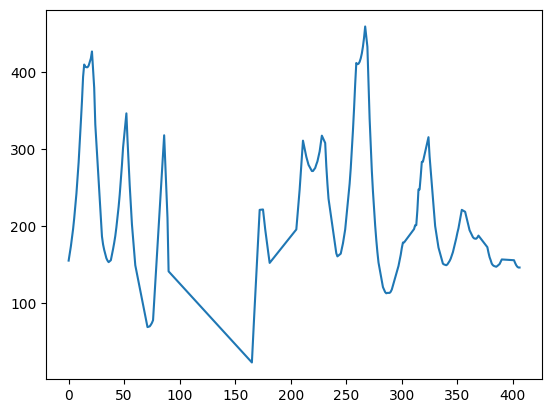

In [19]:
# plot mid_y
plt.plot(df_ball_positions['mid_y'])

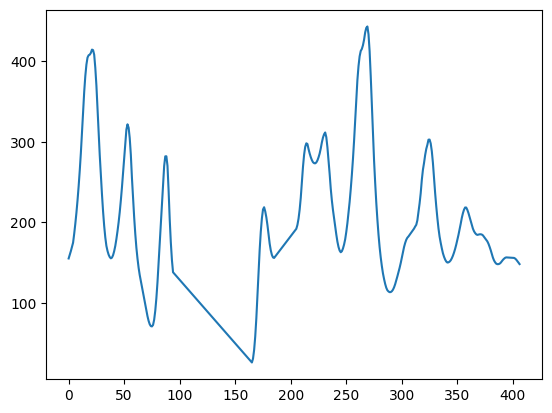

In [20]:
df_ball_positions['mid_y_rolling_mean'] = df_ball_positions['mid_y'].rolling(window=5, min_periods=1, center=False).mean()
plt.plot(df_ball_positions['mid_y_rolling_mean'])

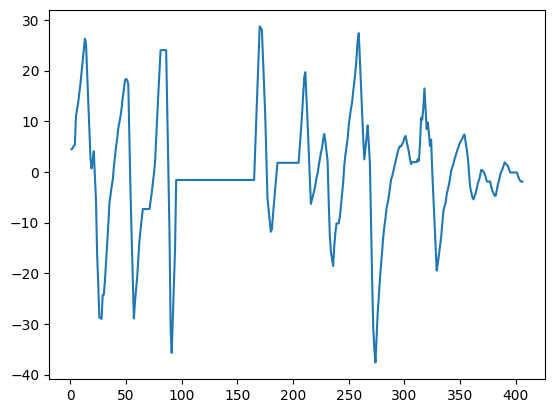

In [21]:
df_ball_positions['delta_y'] = df_ball_positions['mid_y_rolling_mean'].diff()
# plot mid_y_rolling_mean
plt.plot(df_ball_positions['delta_y'])

Position (mid_y) Graph
What it represents: The ball's vertical position over time (frame number).

Y-Axis: Pixel coordinates (e.g., 100 to 450).

Interpretation: Shows where the ball is vertically in the frame.

Key Feature: The curve itself represents the trajectory.

Peaks (lowest y-value) indicate the ball is high in the air.

Valleys (highest y-value) indicate the ball is low, near the court surface.

The slope of this curve at any point is the vertical velocity (delta_y) at that moment.

Use in Hit Detection: Shows the change in direction visually (e.g., a peak followed by a sharp drop).

Velocity (delta_y) Graph
What it represents: The ball's vertical velocity (speed and direction) over time. delta_y is the change in vertical position (mid_y) from one frame to the next.

Y-Axis: Change in pixel coordinates per frame (speed units, e.g., pixels/frame).

Interpretation: Shows how fast and in which direction the ball is moving vertically.

Key Feature: The height and sign of the curve represent the motion.

Positive values mean the ball is moving down (y-coordinate is increasing).

Negative values mean the ball is moving up (y-coordinate is decreasing).

Zero values mean the ball is momentarily stopped vertically (at its apex, or interpolation artifact).

The slope of this curve at any point is the vertical acceleration (accel_y) at that moment.

Use in Hit Detection: Shows the state of motion directly. A sharp, sudden transition from a large positive value to a large negative value (or vice-versa) is the clearest signature of an impact (hit or bounce), as the velocity is instantly reversed.

In [22]:
df_ball_positions['ball_hit']=0

In [32]:
minimum_change_frames_for_hit = 5
for i in range(1,len(df_ball_positions)- int(minimum_change_frames_for_hit*1.2) ):
    negative_position_change = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[i+1] <0
    positive_position_change = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[i+1] >0

    if negative_position_change or positive_position_change:
        change_count = 0
        for change_frame in range(i+1, i+int(minimum_change_frames_for_hit*1.2)+1):
            negative_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] >0 and df_ball_positions['delta_y'].iloc[change_frame] <0
            positive_position_change_following_frame = df_ball_positions['delta_y'].iloc[i] <0 and df_ball_positions['delta_y'].iloc[change_frame] >0

            if negative_position_change and negative_position_change_following_frame:
                change_count+=1
            elif positive_position_change and positive_position_change_following_frame:
                change_count+=1

        if change_count>minimum_change_frames_for_hit-1:
            df_ball_positions['ball_hit'].iloc[i] = 1

frame_nums_with_ball_hits = df_ball_positions[df_ball_positions['ball_hit']==1].index.tolist()

C:\Users\d3smo\AppData\Local\Temp\ipykernel_37972\1602356222.py:18: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_ball_positions['ball_hit'].iloc[i] = 1
C:\Users\d3smo\AppData\Local\Temp\ipykernel_37972\1602356222.py:18: SettingWithCopyWa

In [33]:
df_ball_positions[df_ball_positions['ball_hit']==1]


,x1,y1,x2,y2,mid_y,mid_y_rolling_mean,delta_y,ball_hit
21,311.000000,417.000000,336.000000,437.000000,427.000000,414.700000,4.100000,1
38,542.000000,149.000000,555.000000,162.000000,155.500000,155.150000,-1.600000,1
53,621.000000,303.000000,642.000000,321.000000,312.000000,321.800000,6.500000,1
75,637.000000,68.000000,655.000000,80.000000,74.000000,70.500000,-0.363636,1
88,486.000000,237.666667,502.666667,255.000000,246.333333,282.070000,0.096667,1
165,669.000000,16.000000,685.000000,29.000000,22.500000,25.660000,-1.580000,1
176,674.500000,201.500000,689.500000,215.500000,208.500000,218.700000,2.800000,1
185,685.166667,152.166667,698.666667,166.333333,159.250000,155.625000,-0.650000,1
214,850.000000,282.000000,866.000000,298.000000,290.000000,298.200000,4.400000,1
222,934.000000,267.000000,952.000000,284.000000,275.500000,273.233333,-0.266667,1
